# Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import seaborn as sns
import joblib

# Load Dataset

In [2]:
try:
    df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
    print("Dataset Loaded Successfully.")
    print(df.shape)
except FileNotFoundError:
    print("Error: 'diabetes_012_health_indicators_BRFSS2015.csv' not found.")

Dataset Loaded Successfully.
(253680, 22)


# Drop duplicates

In [3]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]
print(f"Dropped {initial_rows - final_rows} duplicate rows.\n")

Dropped 23899 duplicate rows.



# correleation matrix

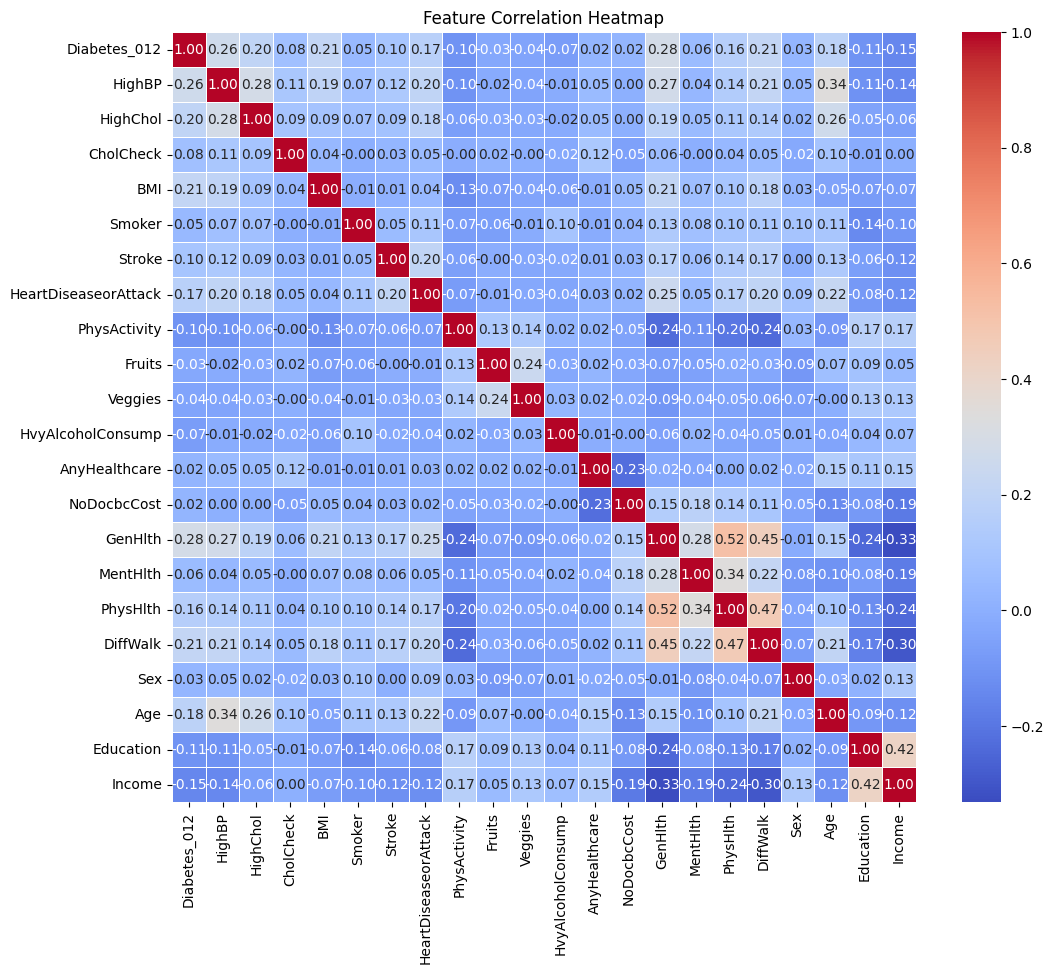

In [4]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Split data

In [6]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(160846, 21) (22978, 21) (45957, 21)


# Scaling 

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Selecting best number of features

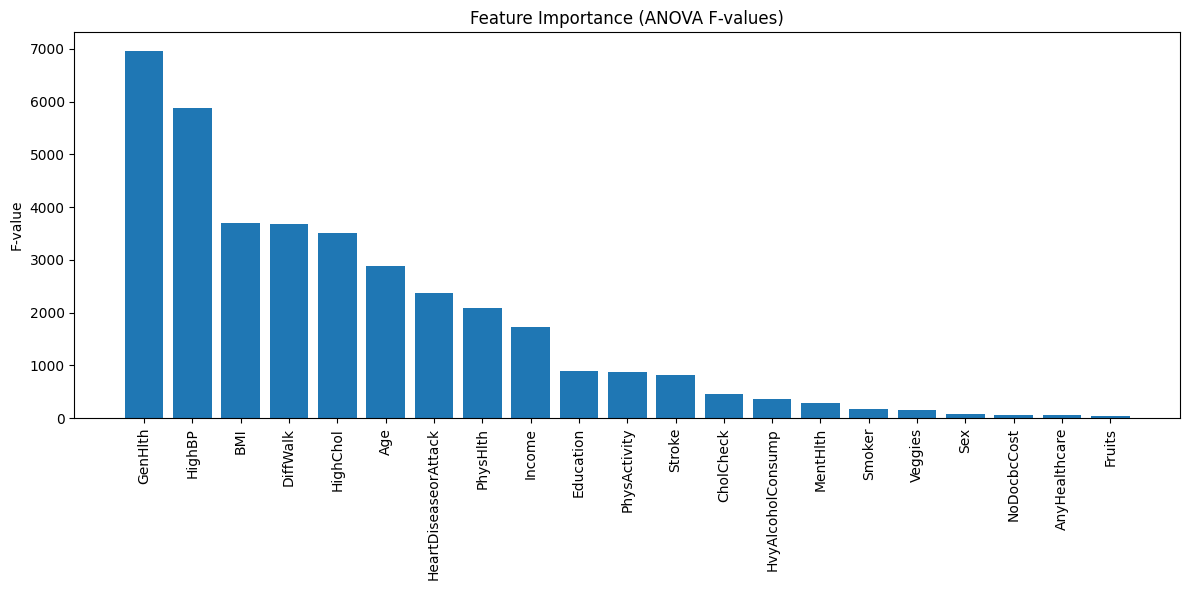

In [ ]:
selector_all = SelectKBest(score_func=f_classif, k='all')
selector_all.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
scores = selector_all.scores_
features = df.drop('Diabetes_012', axis=1).columns

indices = np.argsort(scores)[::-1]

plt.bar(range(len(scores)), scores[indices])
plt.xticks(range(len(scores)), features[indices], rotation=90)
plt.title('Feature Importance (ANOVA F-values)')
plt.ylabel('F-value')
plt.tight_layout()
plt.show()

# Features selection

In [ ]:
# K = 9 is chosen using the elbow method based on the plot of F-values
selector = SelectKBest(score_func=f_classif, k=9)

X_train = selector.fit_transform(X_train, y_train)
X_val = selector.transform(X_val)
X_test = selector.transform(X_test)


# Oversampling (SMOTE)

In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# KNN Hyperparameter Tuning

In [ ]:
k_values = [3, 5, 7, 11, 17, 21,25, 31, 37, 41]
metrics = ['euclidean', 'manhattan', 'chebyshev']

def get_best_knn(X_tr, y_tr, X_v, y_v):
    best_f1 = -1
    best_model = None
    
    for k in k_values:
        for metric in metrics:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(X_tr, y_tr)
            val_preds = knn.predict(X_v)
            
            macro_f1 = f1_score(y_v, val_preds, average='macro')
            
            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_model = knn
                
    return best_model

print("Tuning Baseline KNN...")
best_baseline_knn = get_best_knn(X_train, y_train, X_val, y_val)
print(f"Best Baseline Params: {best_baseline_knn.get_params()}")

print("\nTuning Balanced KNN (SMOTE)...")
best_balanced_knn = get_best_knn(X_train_smote, y_train_smote, X_val, y_val)
print(f"Best Balanced Params: {best_balanced_knn.get_params()}")

Tuning Baseline KNN...
Best Baseline Params: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}

Tuning Balanced KNN (SMOTE)...
Best Balanced Params: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}


# Train and Save Baseline KNN

In [ ]:
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

knn_baseline.fit(X_train, y_train)

joblib.dump(knn_baseline, 'knn_baseline_model.pkl')
print("Baseline model trained and saved as 'knn_baseline_model.pkl'")

Baseline model trained and saved as 'knn_baseline_model.pkl'


# Train and Save Balanced KNN (SMOTE)

In [ ]:
knn_balanced = KNeighborsClassifier(n_neighbors=7, metric='manhattan')

knn_balanced.fit(X_train_smote, y_train_smote)

joblib.dump(knn_balanced, 'knn_balanced_model.pkl')
print("Balanced model trained and saved as 'knn_balanced_model.pkl'")

Balanced model trained and saved as 'knn_balanced_model.pkl'


# Evaluate Baseline KNN

--- Baseline KNN (Imbalanced) ---
Accuracy:    0.8161
F1 Micro:    0.8161
F1 Macro:    0.4018
F1 Weighted: 0.7869



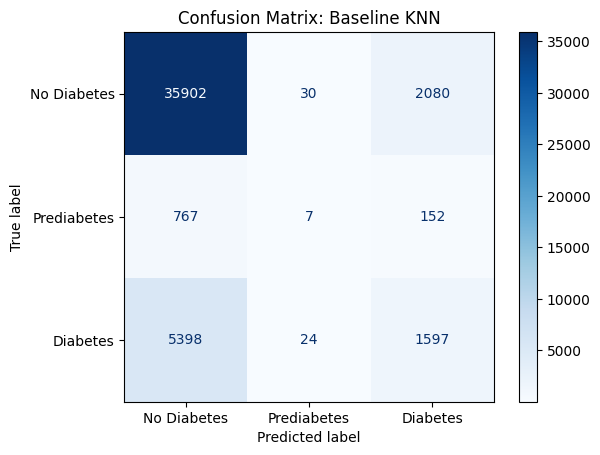

In [ ]:
preds_baseline = knn_baseline.predict(X_test)

print("--- Baseline KNN (Imbalanced) ---")
print(f"Accuracy:    {accuracy_score(y_test, preds_baseline):.4f}")
print(f"F1 Micro:    {f1_score(y_test, preds_baseline, average='micro'):.4f}")
print(f"F1 Macro:    {f1_score(y_test, preds_baseline, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, preds_baseline, average='weighted'):.4f}\n")

cm_baseline = confusion_matrix(y_test, preds_baseline)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=['No Diabetes', 'Prediabetes', 'Diabetes'])
disp_baseline.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Baseline KNN')
plt.show()

# Evaluate Balanced KNN (SMOTE)

--- Balanced KNN (SMOTE) ---
Accuracy:    0.7094
F1 Micro:    0.7094
F1 Macro:    0.4178
F1 Weighted: 0.7422



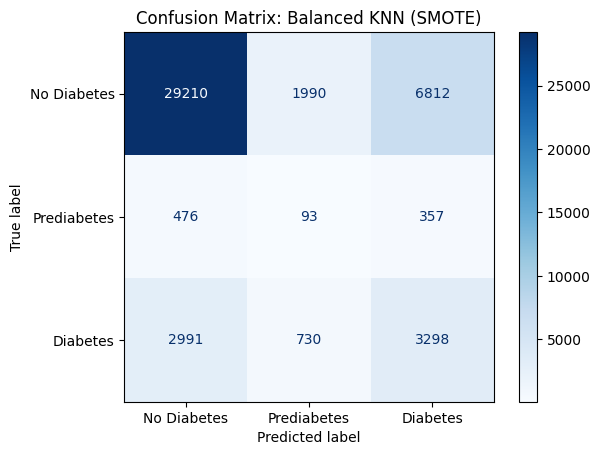

In [ ]:
preds_balanced = knn_balanced.predict(X_test)

print("--- Balanced KNN (SMOTE) ---")
print(f"Accuracy:    {accuracy_score(y_test, preds_balanced):.4f}")
print(f"F1 Micro:    {f1_score(y_test, preds_balanced, average='micro'):.4f}")
print(f"F1 Macro:    {f1_score(y_test, preds_balanced, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, preds_balanced, average='weighted'):.4f}\n")

cm_balanced = confusion_matrix(y_test, preds_balanced)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['No Diabetes', 'Prediabetes', 'Diabetes'])
disp_balanced.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Balanced KNN (SMOTE)')
plt.show()